In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Fashion MNIST dataset
fmnist = tf.keras.datasets.fashion_mnist

In [4]:
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

print("Training images:", training_images.shape)
print("Training labels:", training_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


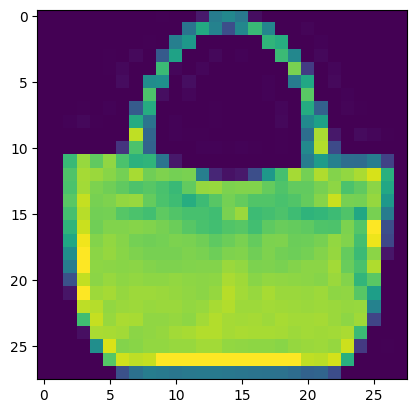

In [6]:
# Visualize a random image

plt.imshow(training_images[100])

# Data Normalization

Before training our neural network, we need to **preprocess the data**.

One of the most important preprocessing steps is **data normalization**.

For the Fashion MNIST dataset, each image is represented by pixel values ranging from **0 to 255**, where:

- **0** represents black.
- **255** represents white.

To make the data easier for the neural network to learn from, we normalize the pixel values by scaling them to a range between **0 and 1**.

```python
training_images = training_images / 255.0
test_images = test_images / 255.0
```

After normalization:

- **0 → 0.0**
- **255 → 1.0**

---

## Why Normalize the Data?

Data normalization is one of the most important preprocessing steps in deep learning. It scales the input data to a smaller, consistent range, making the learning process more efficient and stable.

### 1. Faster Training

Neural networks learn by adjusting their weights using an optimization algorithm such as **Gradient Descent**.

When the input values are very large or have different scales, optimization becomes more difficult.

By normalizing the data, the optimizer converges more quickly, reducing the number of training epochs required.

---

### 2. More Stable Learning

Large input values can produce large activations inside the network, which may lead to unstable gradients during training.

Keeping pixel values between **0 and 1** helps maintain stable weight updates and improves the overall learning process.

---

### 3. Better Model Accuracy

Normalization helps the neural network identify meaningful patterns more effectively.

Without normalization:

- Training can be slower.
- The model may converge to a poorer solution.
- The final accuracy may be lower.

---

### 4. Prevents Numerical Instability

Deep learning models perform millions of mathematical operations during training.

Very large input values can introduce numerical instability, making optimization more difficult.

Normalization keeps computations within a smaller, more manageable range.

---

### 5. Ensures Consistent Feature Scales

Machine learning algorithms generally perform better when all input features have similar scales.

For image data, every pixel represents the same type of feature (brightness). Scaling every pixel to the same range ensures that each feature contributes consistently during training.

---

## Example

| Original Pixel Value | Normalized Value |
|---------------------:|-----------------:|
| 0 | 0.0 |
| 64 | 0.251 |
| 128 | 0.502 |
| 192 | 0.753 |
| 255 | 1.0 |

---

## Summary

Data normalization converts pixel values from **0–255** to **0–1** by dividing every pixel by **255.0**.

### Benefits

- Faster model training
- More stable learning
- Improved numerical stability
- Better model accuracy and generalization
- Consistent feature scaling

Data normalization is considered a **standard preprocessing step** for most computer vision and deep learning applications.

In [7]:
training_images = training_images/255
test_images = test_images/255

# Building the Classification Model

We will build a simple **Artificial Neural Network (ANN)** using TensorFlow's **Keras Sequential API**.

```python
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
```

The model is composed of **three layers**, where the output of one layer becomes the input of the next.

---

## Model Architecture

```text
Input Image (28 × 28)
          │
          ▼
    Flatten Layer
(28 × 28 → 784 values)
          │
          ▼
 Dense Layer (128 neurons)
Activation: ReLU
          │
          ▼
 Dense Layer (10 neurons)
Activation: Softmax
          │
          ▼
Predicted Clothing Class
```

---

# Layer Breakdown

## 1. Flatten Layer

```python
tf.keras.layers.Flatten()
```

### Purpose

The Fashion MNIST images have a shape of:

```text
(28, 28)
```

A neural network made of dense (fully connected) layers expects a **one-dimensional vector** as input.

The `Flatten` layer converts each image from a **28 × 28 matrix** into a **784-element vector**.

### Example

Before:

```text
28 × 28 image
```

After:

```text
[0.0, 0.12, 0.87, ..., 0.45]
```

Length:

```text
28 × 28 = 784 pixels
```

> **Important:** The `Flatten` layer **does not learn any parameters**. It only reshapes the input data.

---

## 2. Hidden Layer (Dense Layer)

```python
tf.keras.layers.Dense(128, activation=tf.nn.relu)
```

### Purpose

This is the first layer that **learns patterns** from the input images.

It contains **128 neurons**, where each neuron receives all **784 input values** from the previous layer.

Each neuron computes a weighted sum of its inputs and applies an activation function.

### Why 128 Neurons?

The number **128** is a design choice (hyperparameter).

- More neurons can capture more complex patterns.
- Too many neurons increase training time and the risk of overfitting.
- Too few neurons may not learn enough information.

For Fashion MNIST, **128 neurons** is a common and effective choice.

---

### ReLU Activation Function

```python
activation=tf.nn.relu
```

ReLU stands for **Rectified Linear Unit**.

Its mathematical definition is:

```text
f(x) = max(0, x)
```

This means:

| Input | Output |
|------:|-------:|
| -4 | 0 |
| -1 | 0 |
| 0 | 0 |
| 3 | 3 |
| 8 | 8 |

### Why Use ReLU?

- Introduces **non-linearity** into the model.
- Makes training faster.
- Helps reduce the **vanishing gradient problem**.
- Is one of the most widely used activation functions in deep learning.

---

## 3. Output Layer

```python
tf.keras.layers.Dense(10, activation=tf.nn.softmax)
```

### Purpose

The final layer produces the model's prediction.

It contains **10 neurons**, one for each Fashion MNIST class.

| Neuron | Clothing Item |
|-------:|---------------|
| 0 | T-shirt / Top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

---

### Softmax Activation

```python
activation=tf.nn.softmax
```

Softmax converts the outputs into **probabilities**.

Example output:

```text
[0.01,
 0.02,
 0.03,
 0.01,
 0.02,
 0.05,
 0.04,
 0.08,
 0.10,
 0.64]
```

The probabilities always:

- Are between **0 and 1**
- Sum to **1.0**

The predicted class is simply the neuron with the **highest probability**.

Example:

```text
Highest probability = 0.64
Predicted label = 9 (Ankle Boot)
```

---

# Summary of the Model

| Layer | Input Shape | Output Shape | Purpose |
|--------|-------------|--------------|---------|
| Flatten | (28, 28) | (784,) | Converts the image into a 1D vector |
| Dense (128, ReLU) | (784,) | (128,) | Learns hidden features and patterns |
| Dense (10, Softmax) | (128,) | (10,) | Outputs the probability for each clothing class |

---

# Complete Data Flow

```text
28 × 28 Image
      │
      ▼
Flatten
      │
      ▼
784 Features
      │
      ▼
128 Hidden Neurons (ReLU)
      │
      ▼
10 Output Neurons (Softmax)
      │
      ▼
Predicted Clothing Category
```

---

# Why This Architecture?

This is a simple **feedforward neural network** that is ideal for introductory image classification tasks such as Fashion MNIST.

It demonstrates the fundamental building blocks of neural networks:

- **Flatten** transforms image data into a format suitable for dense layers.
- **Dense (ReLU)** learns meaningful visual patterns from the input.
- **Dense (Softmax)** converts the learned features into class probabilities, allowing the model to predict the most likely clothing category.

In [8]:
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)]
)

In [10]:
model.compile(optimizer= tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [11]:
#Train the model

model.fit(training_images, training_labels, epochs=50)

Epoch 1/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4982 - accuracy: 0.8259
Epoch 2/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3757 - accuracy: 0.8656
Epoch 3/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3390 - accuracy: 0.8769
Epoch 4/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3151 - accuracy: 0.8846
Epoch 5/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2973 - accuracy: 0.8910
Epoch 6/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2818 - accuracy: 0.8945
Epoch 7/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2720 - accuracy: 0.8982
Epoch 8/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2603 - accuracy: 0.9023
Epoch 9/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2497 - accuracy: 0.9066
Epoch 10/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.241

In [12]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 1ms/step - loss: 0.5108 - accuracy: 0.8876


[0.5107808709144592, 0.8876000046730042]

In [15]:
prediction = model.predict(test_images[0:1])

1/1 [==============================] - 0s 26ms/step


In [16]:
print(prediction)

[[9.58191100e-13 1.20626430e-19 1.02587486e-17 3.44692310e-26
  1.71834823e-13 1.32739875e-09 5.98566155e-16 2.83734209e-07
  1.68410561e-18 9.99999762e-01]]


In [17]:
predicted_label = np.argmax(prediction)
print(predicted_label)

9


In [18]:
print("Predicted:", np.argmax(prediction))
print("Actual:", test_labels[0])

Predicted: 9
Actual: 9
